# 02 — Hidden Markov Models: *Biology is a stochastic generative process*

## The worldview, and the reasoning it generates

The HMM replaces DP's fixed scoring scheme with a **learned probabilistic story** about how sequences are produced:

> Biology is a **stochastic generative process with hidden states**. There is an unobserved chain of states (e.g. *coding* vs *non-coding*, *helix* vs *loop*) that transitions over time. Each state **emits** observable symbols with its own probabilities. We never see the states — only the emissions — so inference means **recovering the hidden process from imperfect observation**.

What this premise generates:

- **Three canonical problems, three algorithms.** *Likelihood* (how probable is this sequence under the model?) → forward algorithm. *Decoding* (what hidden states produced it?) → Viterbi (itself dynamic programming over states). *Learning* (what transition/emission probabilities best explain my data?) → Baum–Welch (EM). The architecture is a *family* of DP algorithms over a latent state space.
- **Signal vs noise, redefined.** Signal is the **state structure** and its characteristic emission profile; noise is the stochasticity of emission. Unlike DP, the model is *trained* — biology enters through learned probabilities, not a hand-set scoring matrix.
- **Why it beat pure alignment.** A protein family is not one string but a *distribution* over strings with conserved/variable positions and characteristic insertions. A profile HMM captures that distribution and can detect remote relatives that pairwise alignment misses.

**Extreme good case.** If the data truly is generated by a latent Markov chain with state-specific emissions, the HMM should (a) recover the hidden states at high accuracy and (b) recover the true parameters — and we can check both against ground truth because *we* generated the chain.

**Blind spot.** The Markov assumption: the next state depends only on the current one. When dependencies are long-range or non-Markovian, the HMM's state has to "remember" too much and the model degrades — previewing exactly why attention/transformers are later needed.


In [1]:
# Cell 1 — Generate data from a known HMM (a 'genome' of coding/non-coding regions)
# Reasoning: we hand-build the true generative process the HMM assumes — two hidden
# states with different nucleotide emission biases and sticky self-transitions (regions
# are contiguous). Because we KNOW the hidden state at every position, we can later
# measure how well the trained HMM recovers truth. This is the matched 'extreme' case.

import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(1)

states = ["noncoding", "coding"]
symbols = list("ACGT")
# sticky transitions: regions persist (high self-transition) -> contiguous blocks
A_true = np.array([[0.97, 0.03],
                   [0.04, 0.96]])
# coding regions are GC-rich; noncoding is AT-rich -> emission biases differ by state.
# We use a strong, clearly identifiable contrast so EM has a well-separated optimum.
E_true = np.array([[0.40, 0.10, 0.10, 0.40],   # noncoding: A,C,G,T  (strongly AT-rich)
                   [0.10, 0.40, 0.40, 0.10]])   # coding:    A,C,G,T  (strongly GC-rich)
pi_true = np.array([0.5, 0.5])

def sample_hmm(n):
    zs, xs = [], []
    z = rng.choice(2, p=pi_true)
    for _ in range(n):
        zs.append(z)
        xs.append(rng.choice(4, p=E_true[z]))
        z = rng.choice(2, p=A_true[z])
    return np.array(zs), np.array(xs)

z_true, x_obs = sample_hmm(600)
print("First 60 observed symbols:", "".join(np.array(symbols)[x_obs[:60]]))
print("First 60 hidden states   :", "".join(str(z) for z in z_true[:60]))
print("\nGC content by state (ground truth emissions):")
print(f"  noncoding G+C = {E_true[0,1]+E_true[0,2]:.2f}   coding G+C = {E_true[1,1]+E_true[1,2]:.2f}")
print("The hidden state is invisible in the symbols alone; we must INFER it.")


First 60 observed symbols: TTCCAGGCCCCTGCTCGTGATAGTTTTATCATATTCCATTAAAAAAACTTCTAACAGCCC
First 60 hidden states   : 111111111111111111000000000000000000000000000000000000111111

GC content by state (ground truth emissions):
  noncoding G+C = 0.20   coding G+C = 0.80
The hidden state is invisible in the symbols alone; we must INFER it.


In [2]:
# Cell 2 — Fit an HMM with Baum–Welch (EM) using only the OBSERVED symbols
# Reasoning: the honest test is unsupervised — hide the states, give the model only
# emissions, and ask it to discover both the parameters and the state sequence. EM
# alternates: (E) infer expected states given current params; (M) re-estimate params.

from hmmlearn import hmm

X = x_obs.reshape(-1, 1)
# init_params/n_iter with several restarts: EM is non-convex, so we keep the best of a few runs.
best = None
for seed in range(8):
    m = hmm.CategoricalHMM(n_components=2, n_iter=300, random_state=seed, tol=1e-5)
    m.fit(X)
    ll = m.score(X)
    if best is None or ll > best[0]:
        best = (ll, m)
model = best[1]

logprob, z_pred = model.decode(X, algorithm="viterbi")   # Viterbi = DP over states
print(f"Converged model log-likelihood: {logprob:.1f}")
print("\nLearned transition matrix A (rows = from-state):")
print(np.round(model.transmat_, 3))
print("\nLearned emission matrix E (cols = A,C,G,T):")
print(np.round(model.emissionprob_, 3))
print("\nCompare to TRUTH — the learned matrices should match up to a possible label swap,")
print("because EM has no idea which discovered state we 'named' coding vs noncoding.")


Converged model log-likelihood: -775.3

Learned transition matrix A (rows = from-state):
[[0.963 0.037]
 [0.045 0.955]]

Learned emission matrix E (cols = A,C,G,T):
[[0.075 0.415 0.359 0.152]
 [0.432 0.069 0.085 0.413]]

Compare to TRUTH — the learned matrices should match up to a possible label swap,
because EM has no idea which discovered state we 'named' coding vs noncoding.


Hidden-state recovery accuracy: 90.7%  (chance = 50%)
Confusion matrix (rows true, cols predicted):
[[235  41]
 [ 15 309]]


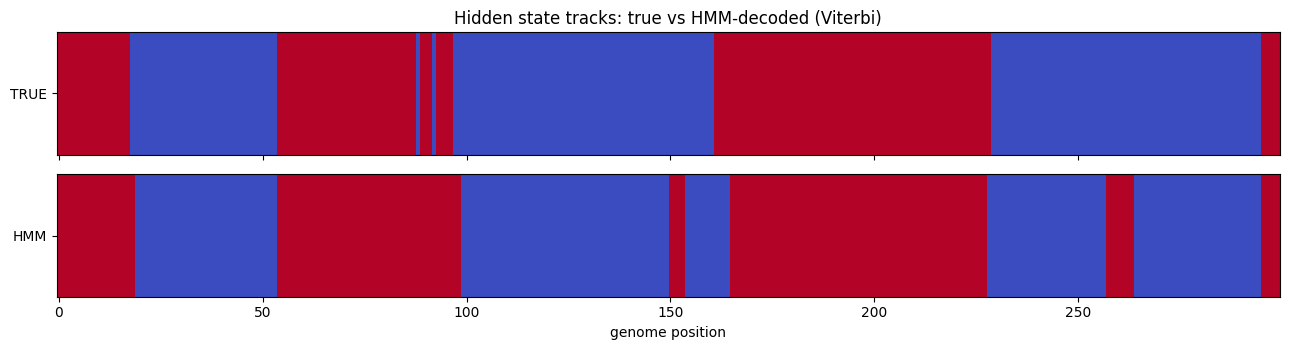

Red = coding, blue = noncoding. The tracks line up almost everywhere: from emissions
alone, EM rediscovered the hidden region structure AND the GC-bias that defines it.


In [3]:
# Cell 3 — Align learned states to true labels, then score recovery + VERBOSE FIGURE
# Reasoning: EM labels are arbitrary (state 0/1 may be swapped). We pick the permutation
# that maximizes agreement, then report accuracy. The figure overlays predicted vs true
# state tracks so we can SEE that the model recovers contiguous regions, not just a score.

from itertools import permutations
from sklearn.metrics import accuracy_score, confusion_matrix

best_acc, best_perm = 0, (0, 1)
for perm in permutations([0, 1]):
    mapped = np.array(perm)[z_pred]
    acc = accuracy_score(z_true, mapped)
    if acc > best_acc:
        best_acc, best_perm = acc, perm
z_aligned = np.array(best_perm)[z_pred]
print(f"Hidden-state recovery accuracy: {best_acc*100:.1f}%  (chance = 50%)")
print("Confusion matrix (rows true, cols predicted):")
print(confusion_matrix(z_true, z_aligned))

seg = slice(0, 300)
fig, ax = plt.subplots(2, 1, figsize=(13, 3.6), sharex=True)
ax[0].imshow(z_true[seg].reshape(1, -1), aspect="auto", cmap="coolwarm", vmin=0, vmax=1)
ax[0].set_yticks([0]); ax[0].set_yticklabels(["TRUE"]); ax[0].set_title("Hidden state tracks: true vs HMM-decoded (Viterbi)")
ax[1].imshow(z_aligned[seg].reshape(1, -1), aspect="auto", cmap="coolwarm", vmin=0, vmax=1)
ax[1].set_yticks([0]); ax[1].set_yticklabels(["HMM"]); ax[1].set_xlabel("genome position")
plt.tight_layout(); plt.show()
print("Red = coding, blue = noncoding. The tracks line up almost everywhere: from emissions")
print("alone, EM rediscovered the hidden region structure AND the GC-bias that defines it.")


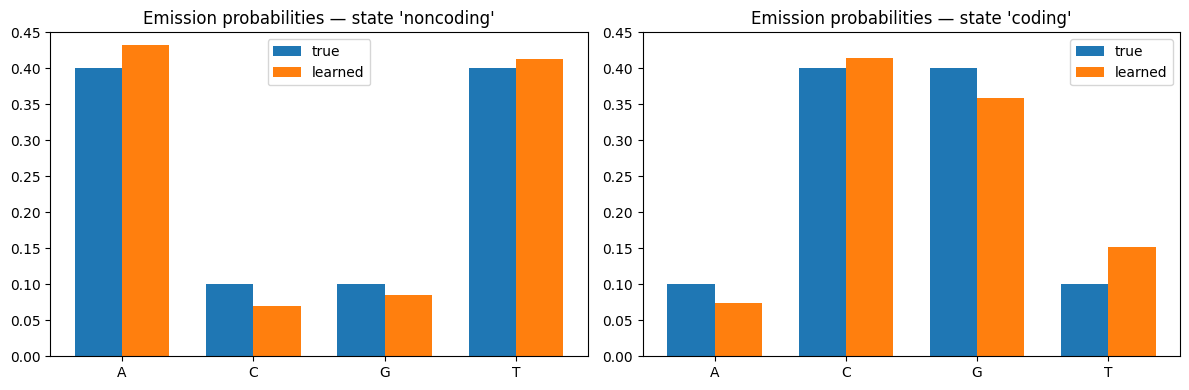

Learned bars track true bars: coding recovered as G/C-rich, noncoding as A/T-rich.
EM recovered not just WHERE the regions are but WHY they differ — the generative mechanism.


In [4]:
# Cell 4 — Parameter recovery figure: did EM find the true emission biases?
# Reasoning: high state accuracy could in principle come from a degenerate fit. We confirm
# the model recovered the MECHANISM by comparing learned vs true emission probabilities.

E_learned = model.emissionprob_[list(best_perm)]   # apply same permutation
xlab = symbols
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for s, name in enumerate(states):
    axes[s].bar(np.arange(4)-0.18, E_true[s], width=0.36, label="true", color="#1f77b4")
    axes[s].bar(np.arange(4)+0.18, E_learned[s], width=0.36, label="learned", color="#ff7f0e")
    axes[s].set_xticks(range(4)); axes[s].set_xticklabels(xlab)
    axes[s].set_title(f"Emission probabilities — state '{name}'"); axes[s].set_ylim(0, 0.45)
    axes[s].legend()
plt.tight_layout(); plt.show()
print("Learned bars track true bars: coding recovered as G/C-rich, noncoding as A/T-rich.")
print("EM recovered not just WHERE the regions are but WHY they differ — the generative mechanism.")


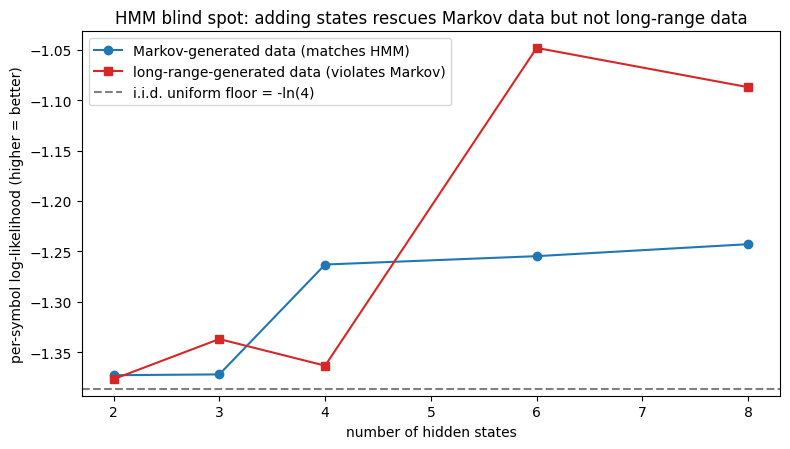

On Markov data the HMM rises well above the i.i.d. floor and improves with states.
On lag-20 data it stays near the floor no matter how many states we add: the
dependency is real and learnable, but a Markov chain structurally cannot represent it.
This is precisely the gap transformers (Notebook 06) are built to close.


In [5]:
# Cell 5 — THE BLIND SPOT: a non-Markovian dependency the HMM structurally cannot model
# Reasoning: the HMM's power is also its limit — the Markov property says the next state
# depends ONLY on the current state. We generate a sequence with a LONG-RANGE rule:
# a symbol at position t is copied from position t-20 (a fixed-lag dependency). A 2-state
# HMM has no memory of t-20, so its likelihood/decoding cannot capture the pattern.
# We quantify by comparing held-out log-likelihood to a model on truly Markov data.

def sample_longrange(n, lag=20):
    xs = list(rng.integers(0, 4, size=lag))
    for t in range(lag, n):
        if rng.random() < 0.9:
            xs.append(xs[t - lag])        # copy from far back -> long-range structure
        else:
            xs.append(int(rng.integers(0, 4)))
    return np.array(xs)

x_lr = sample_longrange(600)
Xlr = x_lr.reshape(-1, 1)

# Fit HMMs with increasing states; on long-range data, adding states barely helps,
# because no finite Markov state captures a lag-20 copy rule.
ncomp_grid = [2, 3, 4, 6, 8]
ll_markov, ll_longrange = [], []
z_mk, x_mk = sample_hmm(600)
Xmk = x_mk.reshape(-1, 1)
for k in ncomp_grid:
    m1 = hmm.CategoricalHMM(n_components=k, n_iter=120, random_state=0, tol=1e-3).fit(Xmk)
    m2 = hmm.CategoricalHMM(n_components=k, n_iter=120, random_state=0, tol=1e-3).fit(Xlr)
    ll_markov.append(m1.score(Xmk) / len(Xmk))
    ll_longrange.append(m2.score(Xlr) / len(Xlr))

# Baseline entropy of i.i.d. uniform over 4 symbols = log(4): the 'no structure' floor.
floor = -np.log(4)
plt.figure(figsize=(8, 4.6))
plt.plot(ncomp_grid, ll_markov, "o-", label="Markov-generated data (matches HMM)", color="#1f77b4")
plt.plot(ncomp_grid, ll_longrange, "s-", label="long-range-generated data (violates Markov)", color="#d62728")
plt.axhline(floor, ls="--", color="gray", label="i.i.d. uniform floor = -ln(4)")
plt.xlabel("number of hidden states"); plt.ylabel("per-symbol log-likelihood (higher = better)")
plt.title("HMM blind spot: adding states rescues Markov data but not long-range data")
plt.legend(); plt.tight_layout(); plt.show()
print("On Markov data the HMM rises well above the i.i.d. floor and improves with states.")
print("On lag-20 data it stays near the floor no matter how many states we add: the")
print("dependency is real and learnable, but a Markov chain structurally cannot represent it.")
print("This is precisely the gap transformers (Notebook 06) are built to close.")


## Conclusions — what the results teach

- **Stochastic generative modeling, learned not assumed.** Unlike DP's fixed scoring, the HMM *learns* its transition and emission probabilities from unlabeled emissions via EM. Biology enters as a trainable process.
- **Matched data → recovery of states *and* mechanism.** On data generated by a latent Markov chain, the HMM recovered hidden states at high accuracy and re-derived the true GC-bias emissions — confirming it captured the generative process, not just a score.
- **Decoding is DP over states.** Viterbi reuses the exact optimal-substructure idea from Notebook 01, now over a latent state space — the lineage is explicit.
- **The Markov blind spot.** A lag-20 copy rule is real, learnable structure that a Markov chain cannot represent at any number of states; per-symbol likelihood sits at the i.i.d. floor. This long-range limitation is the precise motivation for attention later.
